# 01 — Load & Clean
Downloads the raw news parquet, deduplicates, removes short/noisy articles, and filters to AI-related content.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── directories ──────────────────────────────────────────────────────────────
for d in ["data", "outputs", "figures"]:
    Path(d).mkdir(exist_ok=True)

# ── matplotlib style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
})

In [2]:
# ── load raw data ─────────────────────────────────────────────────────────────
df = pd.read_parquet(
    "https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet",
    engine="pyarrow"
)
print(f"Raw shape: {df.shape}")
df.head(2)

Raw shape: (200469, 5)


,url,date,language,title,text
0,http://www.nativestew.com/2024/12/report-on-ba...,2024-12-11,en,"Native Stew - Bahamas AI Art, Photos, Videos: ...","\nNative Stew - Bahamas AI Art, Photos, Videos..."
1,https://bnnbreaking.com/tech/nvidias-gtc-2024-...,2024-03-18,en,Nvidia's GTC 2024 Unveil: New B100 Chip and A...,\n Nvidia's GTC 2024 Unveil: New B100 Chip and...


In [3]:
# ── inspect columns ───────────────────────────────────────────────────────────
print(df.columns.tolist())
print(df.dtypes)

['url', 'date', 'language', 'title', 'text']
url         object
date        object
language    object
title       object
text        object
dtype: object


In [4]:
# ── adapt column names to your actual dataset ─────────────────────────────────
# Change these if your column names differ
TEXT_COL  = "text"
TITLE_COL = "title"
DATE_COL  = "date"

df = df.copy()
df[TEXT_COL]  = df[TEXT_COL].astype(str)
df[TITLE_COL] = df[TITLE_COL].astype(str)

# Combine title + body for richer signal
df["article_text"] = df[TITLE_COL] + ". " + df[TEXT_COL]

# Basic text normalisation
df["article_text"] = (
    df["article_text"]
    .str.replace(r"<[^>]+>", " ", regex=True)   # strip HTML tags
    .str.replace(r"http\S+", " ", regex=True)    # strip URLs
    .str.replace(r"\s+", " ", regex=True)         # collapse whitespace
    .str.strip()
)

df["text_len"] = df["article_text"].str.len()
raw_n = len(df)
print(f"Raw articles: {raw_n:,}")

Raw articles: 200,469


In [5]:
# ── stage 1: deduplicate ──────────────────────────────────────────────────────
df = df.drop_duplicates(subset=["article_text"])
dedup_n = len(df)
print(f"After dedup: {dedup_n:,}  (removed {raw_n - dedup_n:,})")

After dedup: 199,985  (removed 484)


In [6]:
# ── stage 2: remove short / noisy articles ────────────────────────────────────
MIN_LEN = 300   # characters — adjust if needed
df = df[df["text_len"] >= MIN_LEN]
long_n = len(df)
print(f"After length filter (>={MIN_LEN} chars): {long_n:,}  (removed {dedup_n - long_n:,})")

After length filter (>=300 chars): 198,931  (removed 1,054)


In [7]:
# ── stage 3: AI-relevance filter ─────────────────────────────────────────────
AI_KEYWORDS = [
    "artificial intelligence", "machine learning", "deep learning",
    "generative ai", "large language model", "llm", "chatgpt",
    "openai", "automation", "robotics", "computer vision",
    "natural language processing", "nlp", "predictive analytics",
    "neural network", "transformer", "reinforcement learning",
    "gpt", "gemini", "claude", "foundation model"
]

pattern = r"(?i)(" + "|".join(re.escape(k) for k in AI_KEYWORDS) + r")"

df["is_ai_related"] = df["article_text"].str.contains(pattern, regex=True)
df_clean = df[df["is_ai_related"]].copy()
ai_n = len(df_clean)
print(f"After AI filter: {ai_n:,}  (removed {long_n - ai_n:,})")

C:\Users\lola\AppData\Local\Temp\ipykernel_4224\4074795286.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_ai_related"] = df["article_text"].str.contains(pattern, regex=True)


After AI filter: 166,636  (removed 32,295)


In [8]:
# ── parse date & report invalid rows ─────────────────────────────────────────
df_clean[DATE_COL] = pd.to_datetime(df_clean[DATE_COL], errors="coerce")
bad_dates = df_clean[DATE_COL].isna().sum()
print(f"Rows with unparseable dates (kept but NaT): {bad_dates:,}")
print(f"Date range: {df_clean[DATE_COL].min()} → {df_clean[DATE_COL].max()}")

Rows with unparseable dates (kept but NaT): 0
Date range: 2022-01-01 00:00:00 → 2026-04-29 00:00:00


In [9]:
# ── cleaning summary table ────────────────────────────────────────────────────
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Raw articles",
        "After duplicate removal",
        "After removing short/noisy articles",
        "After AI-related filtering"
    ],
    "Articles": [raw_n, dedup_n, long_n, ai_n],
})
cleaning_summary["Removed"] = cleaning_summary["Articles"].shift(1) - cleaning_summary["Articles"]
cleaning_summary["Removed"] = cleaning_summary["Removed"].fillna(0).astype(int)
cleaning_summary["Retained %"] = (cleaning_summary["Articles"] / raw_n * 100).round(1)

cleaning_summary.to_csv("outputs/cleaning_summary.csv", index=False)
cleaning_summary

,Stage,Articles,Removed,Retained %
0,Raw articles,200469,0,100.0
1,After duplicate removal,199985,484,99.8
2,After removing short/noisy articles,198931,1054,99.2
3,After AI-related filtering,166636,32295,83.1


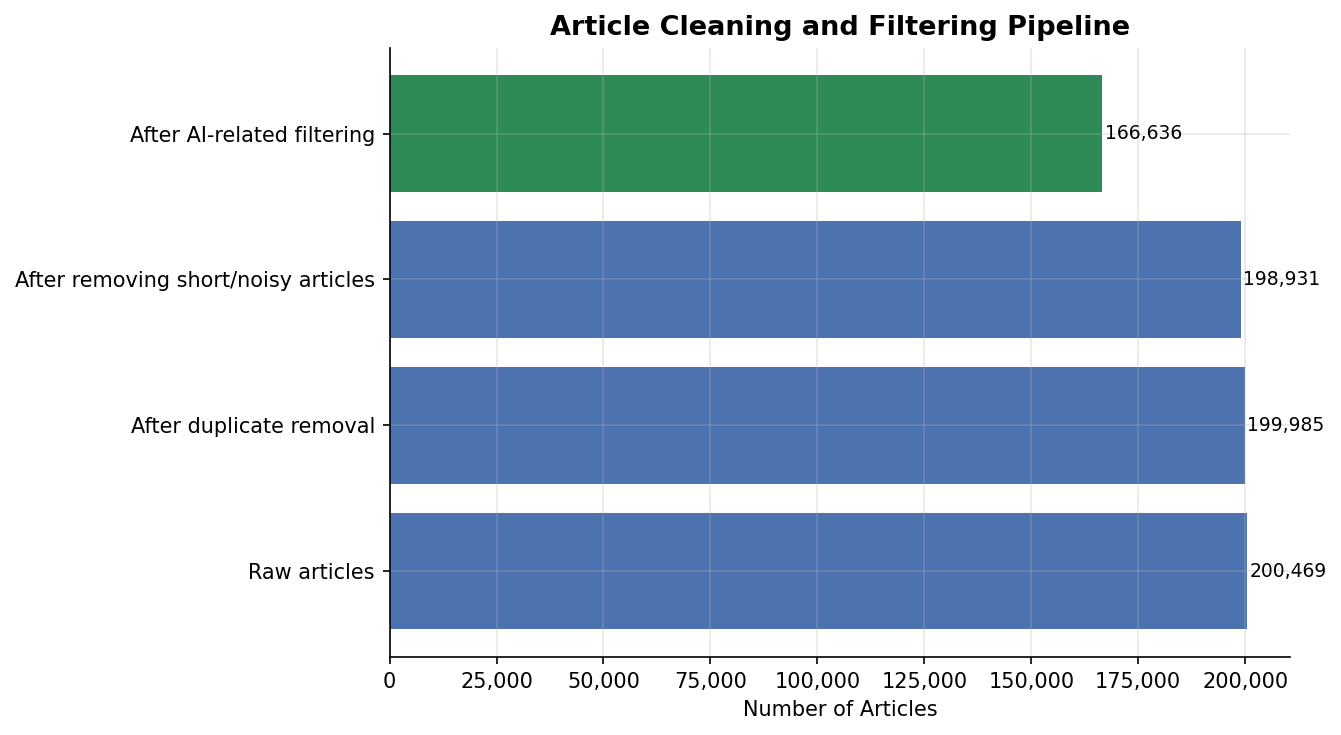

Saved figures/cleaning_pipeline.png


In [10]:
# ── figure: cleaning funnel ───────────────────────────────────────────────────
colors = ["#4C72B0", "#4C72B0", "#4C72B0", "#2E8B57"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    cleaning_summary["Stage"],
    cleaning_summary["Articles"],
    color=colors, edgecolor="none"
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, cleaning_summary["Articles"]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xlabel("Number of Articles")
ax.set_title("Article Cleaning and Filtering Pipeline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/cleaning_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/cleaning_pipeline.png")

In [11]:
# ── save clean data ───────────────────────────────────────────────────────────
df_clean.to_parquet("data/news_clean_ai.parquet", index=False)
print(f"Saved data/news_clean_ai.parquet  ({ai_n:,} rows)")

Saved data/news_clean_ai.parquet  (166,636 rows)
